In [1]:
import pandas as pd
import numpy as np

In [2]:

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

In [3]:
DATA_ROOT = '../data'

healthy_expression = pd.read_csv(f'{DATA_ROOT}/archs4/ARCHS4_healthy_TPM_stricter.tsv', sep = '\t', index_col=0)

In [4]:
female_meta = pd.read_csv(f'{DATA_ROOT}/archs4/ARCHS4_female_healthy_meta.csv', index_col= 0)
male_meta = pd.read_csv(f'{DATA_ROOT}/archs4/ARCHS4_male_healthy_meta.csv', index_col= 0)

In [5]:
male_ids = list(male_meta.index)
female_ids = list(female_meta.index)
all_labelled_ids = male_ids + female_ids

In [6]:
healthy_expression = healthy_expression[all_labelled_ids]

In [7]:
healthy_expression = healthy_expression.T

In [8]:
healthy_expression['sex'] = ''
healthy_expression.loc[male_meta.index, 'sex'] = 'male'
healthy_expression.loc[female_meta.index, 'sex'] = 'female'

In [9]:
X = healthy_expression.drop('sex', axis=1)
y = healthy_expression['sex']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify=y)

In [ ]:
rf = RandomForestClassifier(criterion='gini', random_state= 42)

param_dist = {'bootstrap': [True, False],
              'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None],
              'max_features': ['auto', 'sqrt'],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10],
              'n_estimators': [100, 150, 200, 250, 500, 750, 1000] 
              }

rand_search = RandomizedSearchCV(rf, 
                                 param_distributions = param_dist, 
                                 n_iter=2000, 
                                 cv=5)

rand_search.fit(X_train, y_train)

#keep best model
rf = rand_search.best_estimator_
print(rand_search.best_params_)

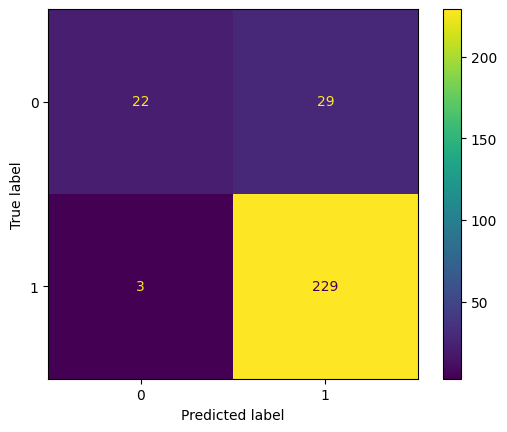

In [ ]:
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

#create and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

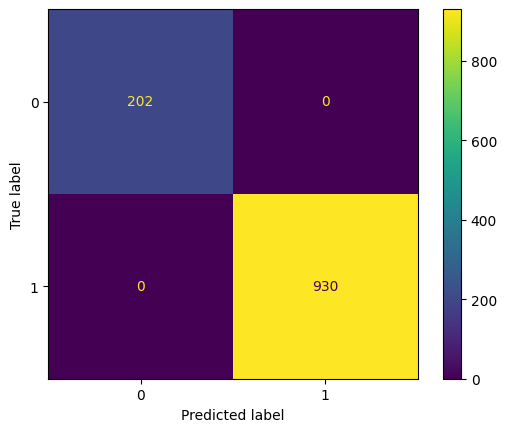

In [ ]:
y_pred = rf.predict(X_train)

#create and plot confusion matrix
cm = confusion_matrix(y_train, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [ ]:
#order genes by importance
RF_feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

RF_feature_importances[0:40].plot.bar();